<a href="https://colab.research.google.com/github/meghanjukl-meg/ICTK_Assignment/blob/main/Task1_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

## Stage 1.1 — Data Loading & Exploratory Data Analysis

#### Load & Inspect

In [3]:
from sklearn.datasets import fetch_california_housing
ch_data = fetch_california_housing()

In [4]:
ch_data.feature_names


['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
print(f"Feature matrix shape: {ch_data.data.shape}")
print(f"Target vector shape: {ch_data.target.shape}")

Feature matrix shape: (20640, 8)
Target vector shape: (20640,)


In [6]:
df = pd.DataFrame(ch_data.data, columns=ch_data.feature_names)
df['MedianHouseVal'] = ch_data.target

In [7]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


#### Descriptive Statistics

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers_count = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
outliers_count

,0
MedInc,681
HouseAge,0
AveRooms,511
AveBedrms,1424
Population,1196
AveOccup,711
Latitude,0
Longitude,0
MedianHouseVal,1071


#### Visualisations

<Figure size 1200x800 with 0 Axes>

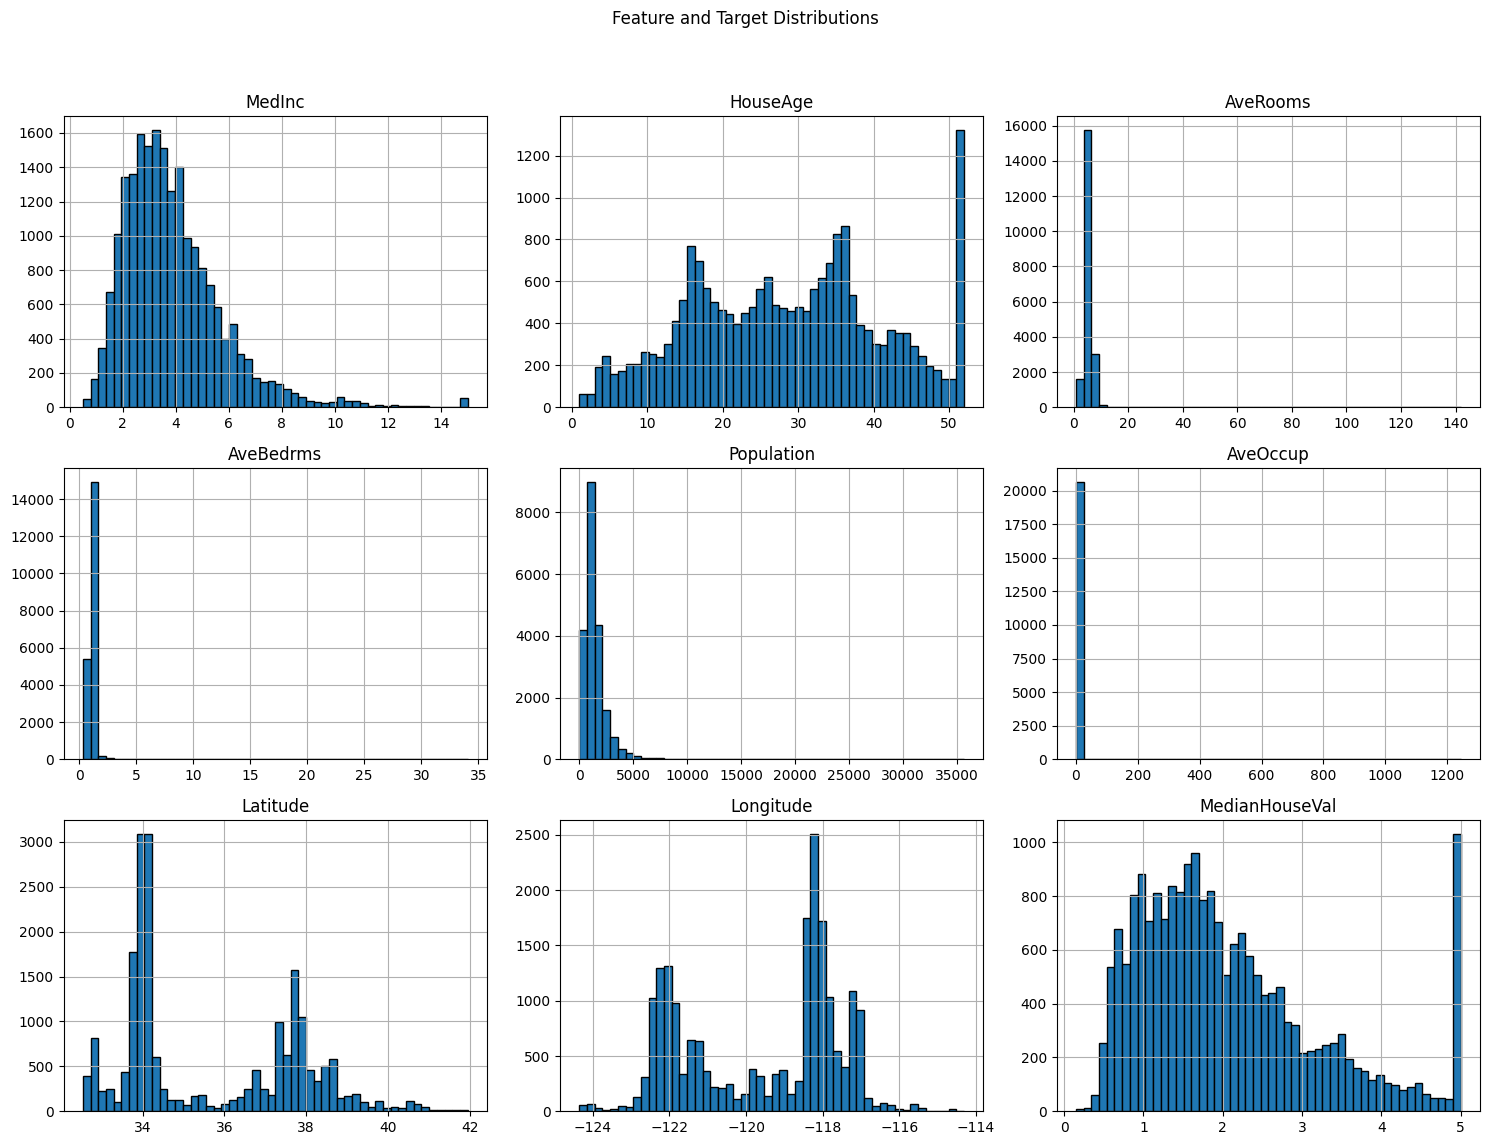

In [10]:
plt.figure(figsize=(12, 8))
df.hist(bins=50, figsize=(15, 12),edgecolor='black')
plt.suptitle("Feature and Target Distributions")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

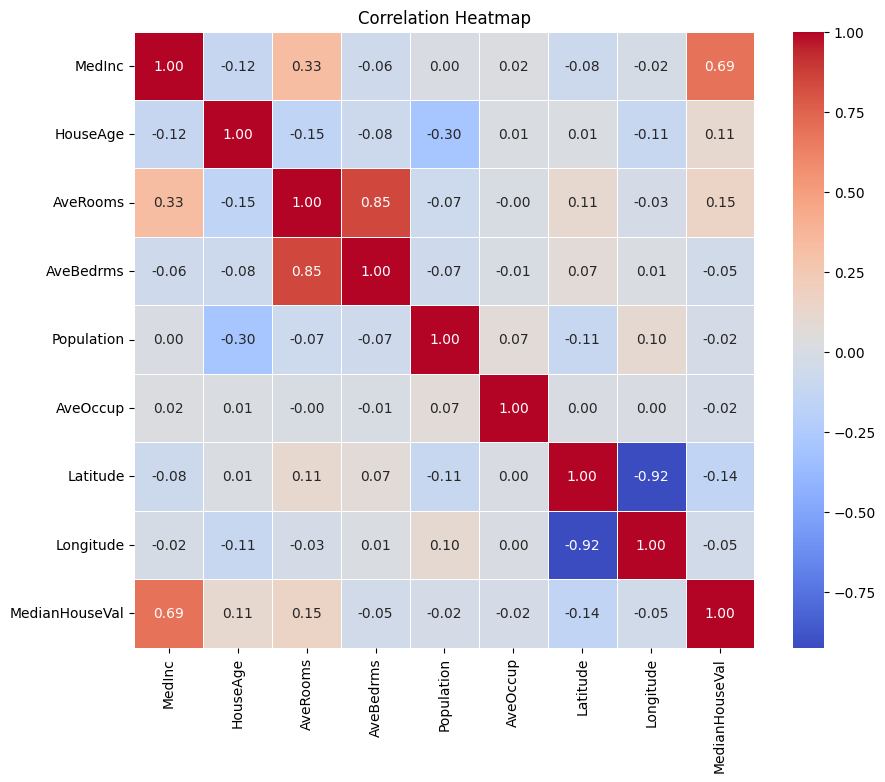

In [11]:
correltn_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correltn_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

MedInc has a  strong correlation with the target(0.69).AveRooms shows a moderate positive correlation

<function matplotlib.pyplot.show(close=None, block=None)>

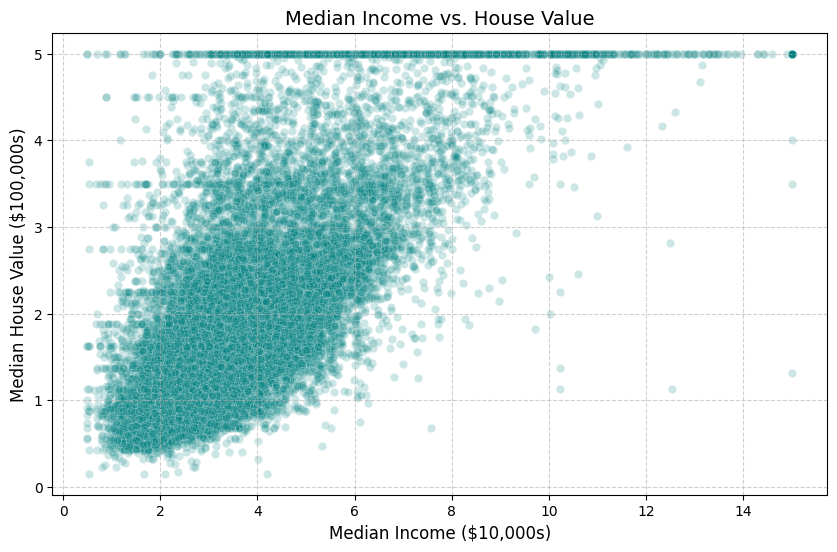

In [12]:
#Scatter plot
#Median Income vs. House Value
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MedInc', y='MedianHouseVal', alpha=0.2, color='teal')
plt.title('Median Income vs. House Value',fontsize=14)
plt.xlabel('Median Income ($10,000s)',fontsize=12)
plt.ylabel('Median House Value ($100,000s)',fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show

As MedInc rises MedianHouseval also tends to rise

<function matplotlib.pyplot.show(close=None, block=None)>

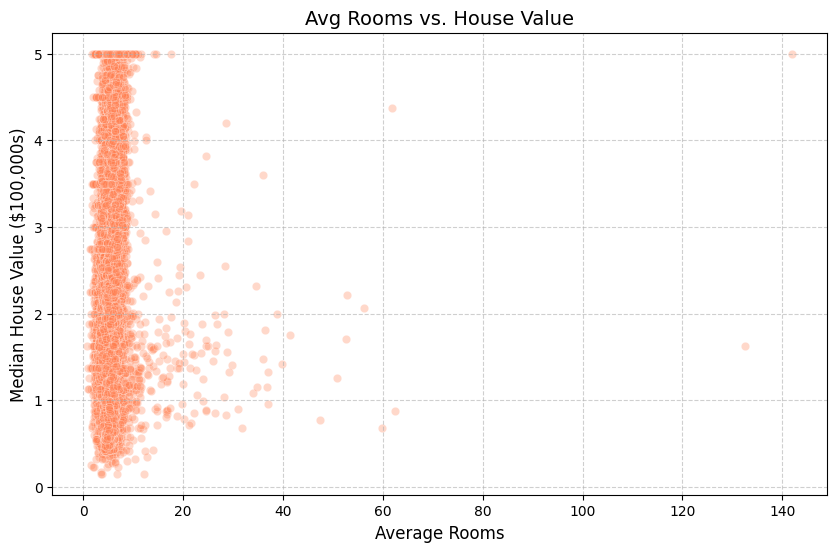

In [13]:
#Average Rooms vs. House Value
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='AveRooms', y='MedianHouseVal', alpha=0.3, color='coral')
plt.title('Avg Rooms vs. House Value',fontsize=14)
plt.xlabel('Average Rooms',fontsize=12)
plt.ylabel('Median House Value ($100,000s)',fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show

## Stage 1.2 — Data Preprocessing

#### Train/Validation/Test Split

training (70%), validation (15%), and test (15%)

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = ch_data.data
y = ch_data.target

Splitting  into 70% Train data  and 30% for the other two(test_size=0.30)

In [16]:
X_train, X_other, y_train, y_other = train_test_split(
    X, y, test_size=0.30, random_state=42
)

Splitting the other 30% into validation (15%) and test (15%).equal halves(test_size=0.50)

In [17]:
X_val, X_test, y_val, y_test = train_test_split(
    X_other, y_other, test_size=0.50, random_state=42
)


JUSTIFICATION:

With 70% Training data the model has a enough  data to learn the underlying patterns and relationships effectively.

Validation data set of 15 % is dedicated to hyperparameter tuning and other decisions. It monitor for overfitting during training

The Testing dataset will give an unbiased final evaluation of the model's performance on an unseen data.

#### Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)

In [20]:
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

It is critical to fit the scaler only on training data to prevent Data leakage

Fitting the scaler on the full dataset would cause data leakage — the model would indirectly 'see' statistics from the validation and test sets during training.

## Stage 1.3 — Model Architecture Design

#### Network design

In [21]:
import tensorflow as tf

In [22]:
model = tf.keras.Sequential([
    # Input Layer + Hidden Layer 1:128 neurons
    tf.keras.layers.Dense(128, activation='relu', input_shape=(8,)),
    #to stabilise
    tf.keras.layers.BatchNormalization(),
    # Hidden Layer 2: 64 neurons
    # using L2 Regularization to prevent the model from giving too much weight to outliers
    tf.keras.layers.Dense(64, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    # Hidden Layer 3: 32 neurons
    tf.keras.layers.Dense(32, activation='relu'),
    # Dropout to prevent overfitting(randomly 'shuts off' 20% of neurons)
    tf.keras.layers.Dropout(0.2),

    # Output Layer: 1 neuron for Regression
    tf.keras.layers.Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Compile

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=['mae', 'mse']
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 256 (1.00 KB)

#### Loss Function — Huber Loss

While MSE is defaullt for regression ,chose Huber Loss because in the data analysis there where significant outliers . Unlike MSE which penalises large errors more heavily,and MAE which is robust for outliers,but lacks the precision of MSE for 'typical' houses,Huber Loss provides a robust quadratic-to-linear transition .It has the Best of Both Worlds.

## Stage 1.4 — Model Training

#### Callbacks

In [25]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

EarlyStopping : By monitoring the loss on the validation set, it ensure the model only continues training as long as its performance on unseen data is improving.

In [26]:
#saving best to a file
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_regression_model.keras',
    monitor='val_loss',
    save_best_only=True
)

ModelCheckpoint:Creates a physical file that only updates when the model hits a new "high score" in validation accuracy.

#### Training

In [27]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3775 - mae: 0.6164 - mse: 0.7487 - val_loss: 0.4008 - val_mae: 0.6493 - val_mse: 0.8274
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2857 - mae: 0.5098 - mse: 0.5139 - val_loss: 0.2532 - val_mae: 0.4557 - val_mse: 0.4596
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2543 - mae: 0.4813 - mse: 0.4652 - val_loss: 0.2013 - val_mae: 0.4016 - val_mse: 0.3549
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2313 - mae: 0.4608 - mse: 0.4332 - val_loss: 0.2037 - val_mae: 0.4185 - val_mse: 0.3870
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2207 - mae: 0.4579 - mse: 0.4292 - val_loss: 0.2055 - val_mae: 0.4325 - val_mse: 0.4075
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2075 - mae: 0.4482 - mse: 0.4130 - val_loss: 0.1752 - val_mae: 0.3951 - val_mse: 0.3495
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1965 - mae: 0.4387 - mse: 0.3970 - val

**Effect of callbacks**

While
Even though epochs was set at 50, the callback "watched" the validation loss and realized that the model had already peaked .During first run it might have around Epoch 14 or 15(patience=10), it waited 10 more rounds to see if the error would drop any further. When it didn't, it killed the process at Epoch 24 to save time and prevent overfitting.
On the second day, It stopped at Epoch 38 because the best score was at Epoch 28, and no better score appeared by Epoch 38, the callback ended the training.

## Stage 1.5 — Plotting & Interpreting Training Curves

#### Training vs. Validation Loss Curve

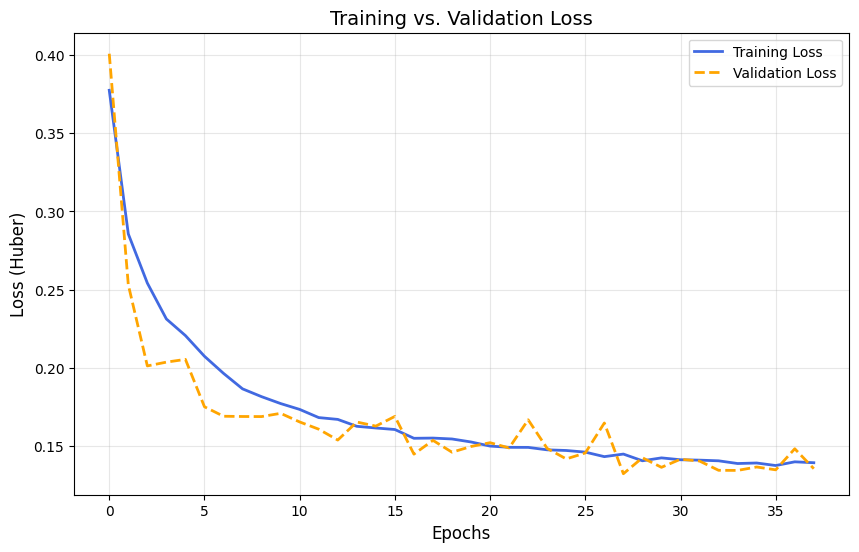

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Training Loss', color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)

plt.title('Training vs. Validation Loss', fontsize=14)

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Huber)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

The model appears well-fitted. Both the training loss and validation loss are on a general downward trend

There is no clear divergence point in this graph ,since the two curves doesnot split in opposite direction .But the validation loss seems a bit bouncy

Here the Validation loss is lower than the Training loss which maybe due to Dropout used.

After epoch 25, the lines are almost flat and overlapping. This means the model has finished learning everything it can with its current setup.

#### Training vs. Validation Metric Curves

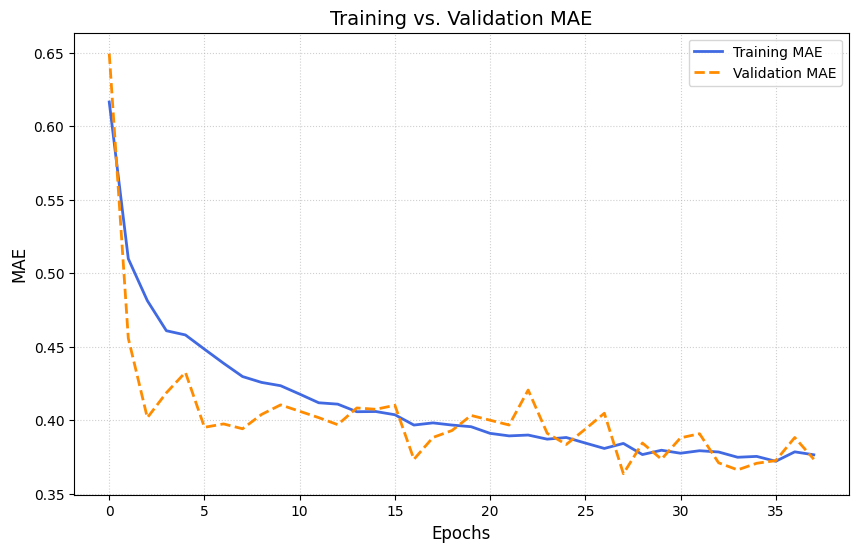

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE', color='royalblue', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', color='darkorange', linestyle='--', linewidth=2)

plt.title('Training vs. Validation MAE', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Both curves show a general downward trend.They both reach a stable "plateau" toward the end of the training session, confirming that the model has converged

The Validation MAE is consistently lower than the Training MAE.


## Stage 1.6 — Model Evaluation & Analysis

#### Test Set Evaluation

In [31]:
result = model.evaluate(X_test_scaled, y_test, verbose=0)

In [32]:
print(f"Test Loss (Huber): {result[0]:.4f}")
print(f"Test MAE:          {result[1]:.4f} ($100k units)")
print(f"Test MSE:          {result[2]:.4f}")

Test Loss (Huber): 0.1238
Test MAE:          0.3516 ($100k units)
Test MSE:          0.2610


#### Prediction Analysis

In [33]:
y_pred = model.predict(X_test_scaled)
y_pred = y_pred.flatten()

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [34]:
comparison_df = pd.DataFrame({'Actual': y_test[:5], 'Predicted': y_pred[:5]})
print(comparison_df)

   Actual  Predicted
0   1.000   0.846432
1   1.188   1.222721
2   3.761   3.160683
3   2.000   1.249665
4   0.952   1.535220


#### Actual vs. Predicted Scatter Plot


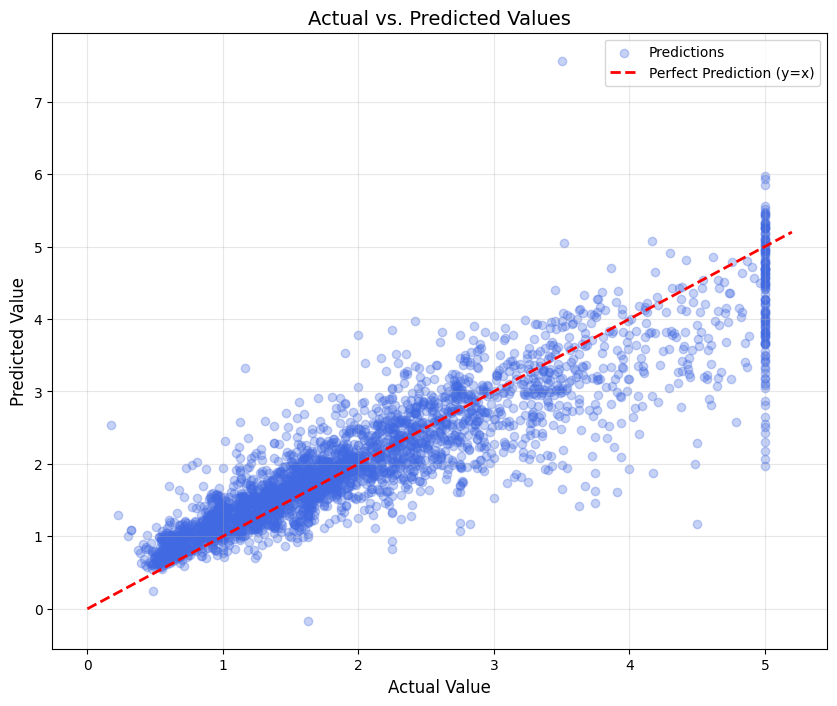

In [35]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='royalblue', label='Predictions')
#The ideal reference line (y = x)
limit_range = [0, 5.2]
plt.plot(limit_range, limit_range, color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
plt.title('Actual vs. Predicted Values', fontsize=14)
plt.xlabel('Actual Value', fontsize=12)
plt.ylabel('Predicted Value', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Most points cluster tightly around the red dashed line

#### Residuals

In [36]:
residuals = y_test - y_pred

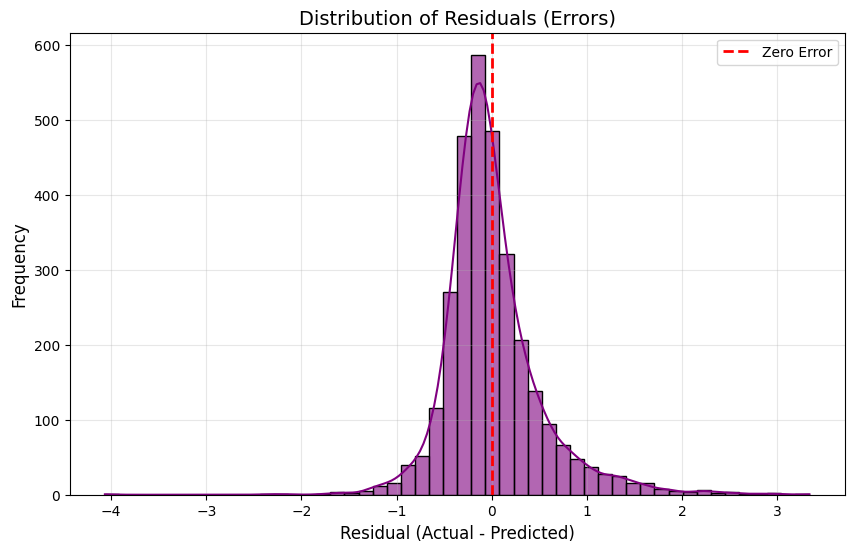

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='purple', alpha=0.6)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.title('Distribution of Residuals (Errors)', fontsize=14)
plt.xlabel('Residual (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

The residuals are approximately normally distributed and it centered near zero(red line)which indicates that the model is "unbiased".
The "tails" are stretching out in  -3 and +3 revealing prediction errors

In [38]:
results_df = pd.DataFrame(X_test, columns=ch_data.feature_names)
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred
results_df['Error'] = results_df['Actual'] - results_df['Predicted']
results_df['AbsError'] = results_df['Error'].abs()

# the top 10 worst predictions
worst_predictions = results_df.sort_values(by='AbsError', ascending=False).head(10)

print("--- Top 10 Largest Prediction Errors ---")
print(worst_predictions[['MedInc', 'AveRooms', 'Actual', 'Predicted', 'Error']])

--- Top 10 Largest Prediction Errors ---
       MedInc   AveRooms   Actual  Predicted     Error
1803  15.0001  22.222222  3.50000   7.565211 -4.065211
321    1.7679   5.000000  4.50000   1.164277  3.335723
2800   4.9757   7.049608  5.00001   1.968447  3.031563
1429   2.7275   5.574286  5.00001   2.071163  2.928847
480    2.3304   1.824719  5.00001   2.180334  2.819676
2362   3.7277   4.765840  5.00001   2.296849  2.703161
1212   6.9930   6.428571  5.00001   2.431789  2.568221
487    6.3406   7.601770  4.48300   1.995495  2.487505
762    3.6728   2.671202  5.00001   2.513537  2.486473
992    4.2386   7.723077  5.00001   2.551505  2.448505


#### Reflections

The model demonstrates strong generalisation capabilities, with a final Test MAE of 0.3516. The fact that test performance slightly exceeds training performance confirms that the Dropout and Batch Normalisation layers successfully prevented overfitting.

 **Improvements**


One would be to remove the censored data points (where MedHouseVal = 5.0) from the training set. Since these points represent an artificial ceiling rather than true market value.

Creating new features based on distance instead of Latitude and Longitude

Applying a Log Transformation to these features before scaling.


 **Hyperparameter choices with the biggest impact**

 Choice to use Standardization (StandardScaler) was the most critical "configuration" for the model.

Dropout & BatchNormalization
 had the biggest impact on Generalization Gap.

Loss Function: Huber Loss treated massive changes with a linear penalty



